In [1]:
from functools import partial
import torch
import torchvision
from torchvision import transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

weights = torchvision.models.ConvNeXt_Base_Weights.IMAGENET1K_V1
model = torchvision.models.convnext_base(weights=weights).to(device)

Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:01<00:00, 203MB/s]


In [2]:

DefaultFlowers102 = partial(torchvision.datasets.Flowers102, root = 'datasets',
                            transform=weights.transforms(), download = True)

train_set = DefaultFlowers102(split = 'train')
valid_set = DefaultFlowers102(split = 'val')
test_set = DefaultFlowers102(split = 'test')

100%|██████████| 345M/345M [00:16<00:00, 21.0MB/s]
100%|██████████| 502/502 [00:00<00:00, 2.04MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 26.5MB/s]


In [3]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size = 32, shuffle = True)
valid_loader = DataLoader(valid_set, batch_size = 32)
test_loader = DataLoader(test_set, batch_size=32)

In [4]:
def plot_image(image):
    plt.imshow(image, cmap="binary")
    plt.axis("off")

In [5]:
class_names = ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle', 'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily', 'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower', 'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy', 'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william', 'carnation', 'garden phlox', 'love in the mist', 'mexican aster', 'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort', 'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily', 'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup', 'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula', 'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium', 'orange dahlia', 'pink-yellow dahlia?', 'cautleya spicata', 'japanese anemone', 'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum', 'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania', 'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory', 'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani', 'clematis', 'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen', 'watercress', 'canna lily', 'hippeastrum', 'bee balm', 'ball moss', 'foxglove', 'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia', 'blanket flower', 'trumpet creeper', 'blackberry lily']

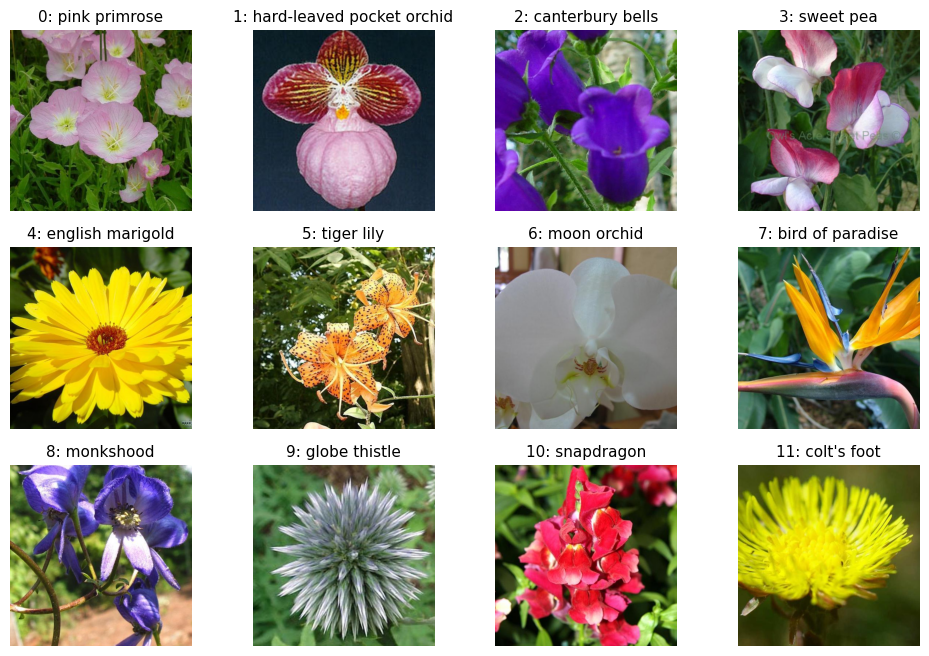

In [6]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.CenterCrop(500)
])

flowers_display = DefaultFlowers102(split = 'train', transform = transform)
sample_flowers = sorted({y: img for img, y in flowers_display}.items())[:12]

import matplotlib.pyplot as plt
plt.figure(figsize = (12, 8))

for class_id , image in sample_flowers:
  if class_id == 12: break
  plt.subplot(3, 4, class_id +1)
  plot_image(image.permute(1,2,0))
  plt.title(f"{class_id}: {class_names[class_id]}", fontsize=11)

plt.show()

In [7]:
[name for name, child in model.named_children()]

['features', 'avgpool', 'classifier']

In [8]:
model.classifier

Sequential(
  (0): LayerNorm2d((1024,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1024, out_features=1000, bias=True)
)

In [9]:
import torch.nn as nn

n_classes = 102
model.classifier[2] = nn.Linear(1024, n_classes).to(device)

In [10]:
for param in model.parameters():
  param.requires_grad = False

for param in model.classifier.parameters():
  param.requires_grad = True

In [11]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 59.5 MB/s eta 0:00:00


In [12]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [13]:
import torchmetrics

n_epochs = 5
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=102).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 4.2611, train metric: 0.1696, valid metric: 0.6020
Epoch 2/5, train loss: 2.9927, train metric: 0.6843, valid metric: 0.7755
Epoch 3/5, train loss: 2.0448, train metric: 0.8343, valid metric: 0.8108
Epoch 4/5, train loss: 1.3544, train metric: 0.9059, valid metric: 0.8559
Epoch 5/5, train loss: 0.9444, train metric: 0.9441, valid metric: 0.8618


In [14]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.6761, train metric: 0.9657, valid metric: 0.8765
Epoch 2/5, train loss: 0.5072, train metric: 0.9647, valid metric: 0.8814
Epoch 3/5, train loss: 0.3936, train metric: 0.9814, valid metric: 0.8853
Epoch 4/5, train loss: 0.3067, train metric: 0.9863, valid metric: 0.8922
Epoch 5/5, train loss: 0.2516, train metric: 0.9902, valid metric: 0.8873


In [15]:
for param in model.parameters():
    param.requires_grad = True

# AFter trained with freezing parameters now we can use the model weights on

In [16]:
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.6556, train metric: 0.8098, valid metric: 0.8010
Epoch 2/5, train loss: 0.2135, train metric: 0.9373, valid metric: 0.8500
Epoch 3/5, train loss: 0.1597, train metric: 0.9588, valid metric: 0.8392
Epoch 4/5, train loss: 0.1051, train metric: 0.9667, valid metric: 0.8324
Epoch 5/5, train loss: 0.1843, train metric: 0.9431, valid metric: 0.8098


In [17]:
from torchvision.transforms import v2

transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(224),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [18]:
class FlowerLocator(nn.Module):
  def __init__(self, base_model):
    super().__init__()

    self.base_model = base_model
    self.localization_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(base_model.classifier[2].in_features, 4)
        )

  def forward(self, X):
    features = self.base_model.features(X)
    pool = self.base_model.avgpool(features)
    y_pred_logits = self.base_model.classifier(pool)
    y_pred_bbox = self.localization_head(pool)
    return y_pred_logits, y_pred_bbox

torch.manual_seed(42)
locator_model = FlowerLocator(model).to(device)

# We created a Multi class neural network which gets the predicted model image and add another prediction to detect the four edges around an image to give bounding box

In [19]:
from sklearn.datasets import load_sample_images
import numpy as np

sample_images = np.stack(load_sample_images()["images"])
sample_images = torch.tensor(sample_images, dtype=torch.float32) / 255

In [20]:
sample_images_permuted = sample_images.permute(0, 3, 1, 2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

In [21]:
img = torchvision.tv_tensors.Image(sample_images_permuted[0])

In [22]:
import torchvision.tv_tensors

bbox = torchvision.tv_tensors.BoundingBoxes(
    [[377, 199, 248, 262]],
    format = "CXCYWH",
    canvas_size = (500, 754)
)

In [23]:
out_img, out_bbox = transform(img, bbox)

In [24]:
print("Transformed Box:", out_bbox)

Transformed Box: BoundingBoxes([[112,  85, 126, 134]], format=BoundingBoxFormat.CXCYWH, canvas_size=(224, 224), clamping_mode=soft)


In [25]:
torch.manual_seed(42)

# load the first training image without any preprocessing
first_image = torchvision.datasets.Flowers102(root="datasets", split="train")[0][0]

preproc_image, preproc_target = transform(
    (img, {"label": 0, "bbox": bbox})
)
preproc_bbox = preproc_target["bbox"]

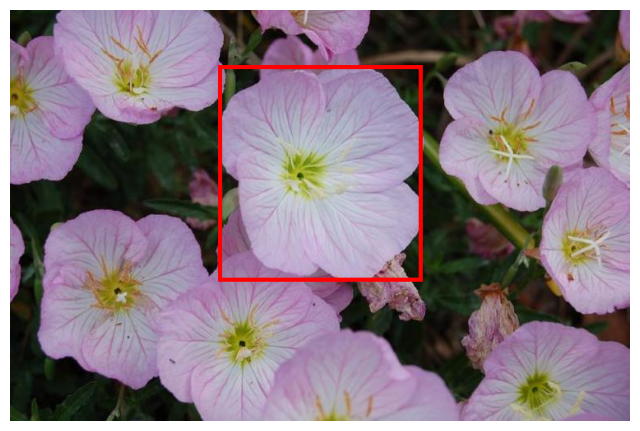

In [26]:
import torch
import torchvision
import torchvision.transforms.v2 as T
import matplotlib.pyplot as plt

def plot_image(image):
    plt.figure(figsize=(8, 6))
    plt.imshow(image.permute(1, 2, 0))
    plt.axis("off")

def get_image_with_bbox(image, bbox, width=5, color="red"):
    # box_convert handles the math to change Center/Width format to Corner coordinates
    bbox_xyxy = torchvision.ops.box_convert(bbox, in_fmt="cxcywh", out_fmt="xyxy")

    return torchvision.utils.draw_bounding_boxes(
        image,
        bbox_xyxy,
        width=width,
        colors=color
    )

first_image_ts = T.ToImage()(first_image)

#'bbox' is the variable created earlier with tv_tensors.BoundingBoxes
image_with_bbox = get_image_with_bbox(first_image_ts, bbox, width=5, color="red")

plot_image(image_with_bbox)
plt.show()

In [36]:
import torch
import random
import torchvision
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

class SyntheticFlowerDetection(Dataset):
    def __init__(self, base_dataset, canvas_size=224):
        self.base_dataset = base_dataset
        self.canvas_size = canvas_size

        self.format_flower = T.Compose([
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
        ])

        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]

        # Random size between 50 pixels (tiny) and 180 pixels (huge)
        random_w = random.randint(50, 180)
        random_h = random.randint(50, 180)

        # Resize the flower to that random size
        resizer = T.Resize((random_h, random_w))
        img_resized = resizer(img)

        img_small = self.format_flower(img_resized)

        canvas = torch.zeros((3, self.canvas_size, self.canvas_size), dtype=torch.float32)

        # Calculate positions based on the NEW random size
        max_x_offset = self.canvas_size - random_w
        max_y_offset = self.canvas_size - random_h

        x = random.randint(0, max_x_offset)
        y = random.randint(0, max_y_offset)

        canvas[:, y:y+random_h, x:x+random_w] = img_small

        cx = x + (random_w / 2.0)
        cy = y + (random_h / 2.0)
        w = float(random_w)
        h = float(random_h)

        bbox = torch.tensor([cx, cy, w, h], dtype=torch.float32)

        final_image = self.normalize(canvas)

        return final_image, label, bbox

base_dataset = torchvision.datasets.Flowers102(root="datasets", split="test", download=True)
synth_dataset = SyntheticFlowerDetection(base_dataset)
train_loader = DataLoader(synth_dataset, batch_size=32, shuffle=True)

print(f"Synthetic Dataset Created. Size: {len(synth_dataset)}")

Synthetic Dataset Created. Size: 6149


In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

locator_model = locator_model.to(device)

optimizer = optim.Adam(locator_model.parameters(), lr=1e-4)
criterion_class = nn.CrossEntropyLoss()
criterion_bbox = nn.MSELoss()

num_epochs = 5
print("Starting Training...")

for epoch in range(num_epochs):
    locator_model.train()
    total_loss = 0
    bbox_loss_sum = 0

    for images, labels, true_bboxes in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        true_bboxes = true_bboxes.to(device)

        optimizer.zero_grad()

        # Forward Pass
        pred_logits, pred_bboxes = locator_model(images)

        # Classification Loss
        loss_cl = criterion_class(pred_logits, labels)

        # Localization Loss
        loss_bb = criterion_bbox(pred_bboxes, true_bboxes)

        loss = loss_cl + (loss_bb * 0.001)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        bbox_loss_sum += loss_bb.item()

    avg_loss = total_loss / len(train_loader)
    avg_bbox = bbox_loss_sum / len(train_loader)
    print(f"Epoch {epoch+1} | Total Loss: {avg_loss:.4f} | BBox MSE: {avg_bbox:.2f}")

print("Training Complete!")

Starting Training...
Epoch 1 | Total Loss: 0.6623 | BBox MSE: 481.85
Epoch 2 | Total Loss: 0.3921 | BBox MSE: 251.04
Epoch 3 | Total Loss: 0.1985 | BBox MSE: 81.59
Epoch 4 | Total Loss: 0.1396 | BBox MSE: 53.79
Epoch 5 | Total Loss: 0.1391 | BBox MSE: 44.33
Training Complete!


True Box:      [118.0, 62.0, 106.0, 114.0]
Predicted Box: [120.91287994384766, 58.700191497802734, 98.8691635131836, 111.19332885742188]


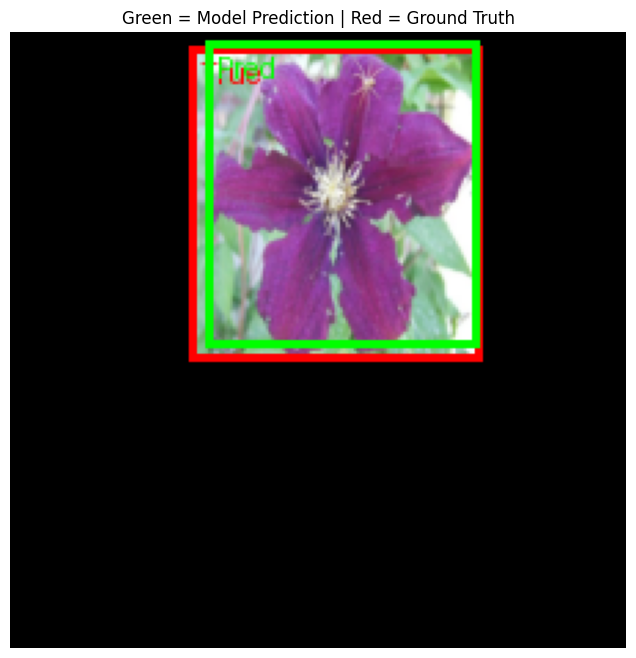

In [38]:
sample_idx = random.randint(0, len(synth_dataset)-1)
img_tensor, label, true_bbox = synth_dataset[sample_idx]

locator_model.eval()
with torch.no_grad():
    input_batch = img_tensor.unsqueeze(0).to(device)
    pred_logits, pred_bbox = locator_model(input_batch)

pred_box_cpu = pred_bbox[0].cpu()
print(f"True Box:      {true_bbox.tolist()}")
print(f"Predicted Box: {pred_box_cpu.tolist()}")

def unnormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

pred_xyxy = torchvision.ops.box_convert(pred_box_cpu, "cxcywh", "xyxy")
true_xyxy = torchvision.ops.box_convert(true_bbox, "cxcywh", "xyxy")

show_img = unnormalize(img_tensor).clamp(0,1)
show_img = (show_img * 255).to(torch.uint8)

res_img = torchvision.utils.draw_bounding_boxes(
    show_img,
    torch.stack([true_xyxy, pred_xyxy]),
    labels=["True", "Pred"],
    colors=["red", "lime"],
    width=3
)

plt.figure(figsize=(8, 8))
plt.imshow(res_img.permute(1, 2, 0))
plt.axis("off")
plt.title("Green = Model Prediction | Red = Ground Truth")
plt.show()

Predicted Box: [[15.19049072265625, 14.823638916015625, 206.06405639648438, 204.08349609375]]


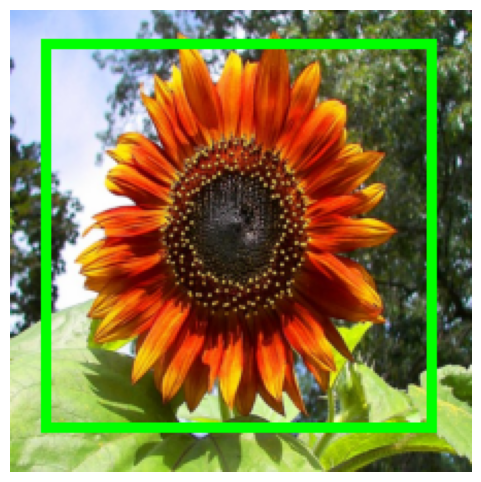

In [39]:
import requests
from PIL import Image
from io import BytesIO

url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})
raw_img = Image.open(BytesIO(response.content)).convert("RGB")

# We recreate the transform here to ensure it's correct for inference
inference_tf = T.Compose([
    T.Resize((224, 224)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

input_tensor = inference_tf(raw_img).unsqueeze(0).to(device)

locator_model.eval()
with torch.no_grad():
    logits, pred_bbox = locator_model(input_tensor)

pred_box = pred_bbox[0]
bbox_xyxy = torchvision.ops.box_convert(pred_box, "cxcywh", "xyxy")
safe_box = torch.stack([
    bbox_xyxy[0].clamp(0, 224), bbox_xyxy[1].clamp(0, 224),
    bbox_xyxy[2].clamp(0, 224), bbox_xyxy[3].clamp(0, 224)
]).unsqueeze(0)

print(f"Predicted Box: {safe_box.tolist()}")

def denorm(t): return (t * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(device) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(device))
img_vis = (denorm(input_tensor[0]).clamp(0,1) * 255).to(torch.uint8)

res_img = torchvision.utils.draw_bounding_boxes(img_vis, safe_box, colors="lime", width=5)

plt.figure(figsize=(6, 6))
plt.imshow(res_img.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()